# Sparkles training console (simple)

Interactive wrapper around the same Python APIs as the CLI. Edit **parameters** below, then run **single-train** or **grid-search** cells.

**Setup** (once, from repo root):

```bash
pip install -e ".[dev,notebook,ml]"   # ml = XGBoost
jupyter notebook notebooks/sparkles_train_console.ipynb
```

After `pip install` or pulling new code: **Kernel → Restart**.

**Config cells:** `CONFIG_PATH` = full experiment under `configs/experiments/` (has `symbol`, dates, barriers). **`presets/`** files are overlays only — set `PRESET_PATH`, not `CONFIG_PATH`, to those.

**Run modes** (set `RUN_MODE` in the parameters cell):

| Mode | What to run |
|------|-------------|
| `"single"` | Dry-run → Train cells (one experiment via `OVERRIDES`) |
| `"grid"` | Grid preview → Grid train cells (cartesian sweep via inline `GRID_SPEC` or `GRID_YAML_PATH`) |

Grid uses dotted paths like `model.xgb_learning_rate` — same as `scripts/run_grid_search.py`. All runs append to **`experiments.jsonl`**; the trials table at the bottom picks them up.

Prerequisites: `sparkles ingest` and `sparkles label` for **`CONFIG_PATH`** (same as CLI).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd

# Repo root (parent of notebooks/)
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "sparkles").is_dir():
    REPO_ROOT = Path.cwd().parent
if not (REPO_ROOT / "sparkles").is_dir():
    raise RuntimeError("Open this notebook from the Sparkles repo root or notebooks/ folder")

import os
os.chdir(REPO_ROOT)

# Prefer repo source over a stale site-packages install (then restart kernel once).
_repo_src = str((REPO_ROOT / "sparkles").resolve().parent)
if _repo_src not in sys.path:
    sys.path.insert(0, _repo_src)

from sparkles.env import load_dotenv
load_dotenv()

import sparkles
from sparkles.config.schema import FeatureConfig

# If you added G1/G2 features in OVERRIDES but this fails, restart the kernel after:
#   pip install -e ".[dev,notebook,ml]"
_g1_fields = ("returns_multi_horizon", "realized_vol_multi", "range_vol_multi")
_g2_fields = ("session_time", "volume_context", "volume_median_window_bars", "vwap_distance")
_g3_fields = ("bar_microstructure", "market_context", "market_spy_return_bars")
_has_g1_schema = all(f in FeatureConfig.model_fields for f in _g1_fields)
_has_g2_schema = all(f in FeatureConfig.model_fields for f in _g2_fields)
_has_g3_schema = all(f in FeatureConfig.model_fields for f in _g3_fields)

print("Working directory:", REPO_ROOT.resolve())
print("sparkles loaded from:", Path(sparkles.__file__).resolve())
print("TWELVEDATA_API_KEY loaded:", bool(os.environ.get("TWELVEDATA_API_KEY", "").strip()))
print("Phase G1 schema:", "OK" if _has_g1_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G2 schema:", "OK" if _has_g2_schema else "MISSING — run pip install -e . and Restart Kernel")
print("Phase G3 schema:", "OK" if _has_g3_schema else "MISSING — run pip install -e . and Restart Kernel")

Working directory: C:\Users\micha\PyProjects\Sparkles
sparkles loaded from: C:\Users\micha\PyProjects\Sparkles\sparkles\__init__.py
TWELVEDATA_API_KEY loaded: True
Phase G1 schema: OK
Phase G2 schema: OK
Phase G3 schema: OK


In [2]:
# --- Edit these knobs ---
# Full experiment YAML (symbol, dates, barriers, stride) — NOT a presets/ overlay file.
CONFIG_PATH = REPO_ROOT / "configs/experiments/rklb_daytrade_v2.yaml"
# Optional preset merged on top of CONFIG_PATH (train/features/model tweaks). None = skip.
PRESET_PATH: Path | None = REPO_ROOT / "configs/experiments/presets/rklb_daytrade_v2_g1.yaml"
# Merged last — overrides preset where keys overlap. Tune model: / preprocess: here.
OVERRIDES: dict = {
    "train": {
        "experiment_name": "Trial_RB_G1_G2_G3_v4.1",
        "notes": "Day-trade v2 + G1/2/3 + SPY / VIX + I4 unique",
        "export_predictions": "val",
    },
    "model": {
        "type": "xgboost_classifier",
        "random_seed": 42,
        "class_weight": "balanced",
        "xgb_max_depth": 3,
        "xgb_n_estimators": 255,
        "xgb_learning_rate": 0.02,
        "xgb_subsample": 0.8,
        "xgb_colsample_bytree": 0.8,
    },
    "preprocess": {
        "scaler": "none",
    },
    "features": {
        "returns_multi_horizon": True,
        "realized_vol_multi": True,
        "range_vol_multi": True,
        "returns_horizons_bars": [1, 5, 10, 15, 30, 60],
        "realized_vol_windows_bars": [5, 10, 15, 30],
        "realized_vol_include_ratio": True,
        "range_vol_window_bars": 10,
        "range_vol_include_atr_norm": True,
        # G2 — set True to A/B vs G1-only (or use PRESET_PATH = .../rklb_daytrade_g1_g2_v1.yaml)
        "session_time": True,
        "volume_context": True,
        "volume_median_window_bars": 60,
        "vwap_distance": True,
        # G3 — bar microstructure is OHLC-only; market_context needs sparkles ingest (SPY/VIX)
        "bar_microstructure": True,
        "market_context": True,
        "market_spy_return_bars": 15,
    },
}

DO_DRY_RUN = True   # check splits / class balance
DO_TRAIN = True     # set False to skip fit

# --- Run mode: "single" (one train) or "grid" (cartesian sweep) ---
RUN_MODE = "single"  # "single" | "grid"

# Grid search (when RUN_MODE == "grid") — uses same CONFIG_PATH + PRESET_PATH as single run
GRID_FROM_YAML = False
GRID_YAML_PATH = REPO_ROOT / "configs/experiments/grids/rklb_daytrade_xgb_v1.yaml"
GRID_SPEC: dict = {
    "experiment_name_prefix": "nb_grid_xgb",
    "notes_prefix": "Notebook grid",
    "fixed": {"train.export_predictions": "none"},  # faster grids; set "val" for backtest follow-up
    "params": {
        "model.xgb_n_estimators": [60, 127, 255],
        "model.xgb_learning_rate": [0.02, 0.08],
        "model.xgb_max_depth": [3, 4],
        # "features.market_spy_return_bars": [5, 15, 30],
        # "train.sample_weight_method": ["none", "uniqueness"],
    },
}
DO_GRID_DRY_RUN = True   # preview each combo (row counts / features)
DO_GRID_TRAIN = False    # set True to fit all combinations (~seconds each)

In [3]:
from sparkles.config.load import (
    deep_merge_mappings,
    load_experiment_config,
    load_experiment_config_merged,
)
from sparkles.config.schema import ExperimentConfig
from sparkles.data.ingest import parquet_cache_path
from sparkles.labels.triple_barrier import labeled_parquet_path

if PRESET_PATH is not None:
    cfg = load_experiment_config_merged(CONFIG_PATH, PRESET_PATH)
else:
    cfg = load_experiment_config(CONFIG_PATH)

if OVERRIDES:
    merged = deep_merge_mappings(cfg.model_dump(mode="json"), OVERRIDES)
    cfg = ExperimentConfig.model_validate(merged)

ingest_path = parquet_cache_path(cfg, base_dir=REPO_ROOT)
label_path = labeled_parquet_path(cfg, base_dir=REPO_ROOT)

print(f"symbol={cfg.symbol}  model.type={cfg.model.type}")
print(f"barriers: TP={cfg.profit_barrier_base} SL={cfg.stop_loss_base} vertical_days={cfg.vertical_max_trading_days} stride={cfg.label_entry_stride}")
print(f"train={cfg.train_start}..{cfg.train_end}  val={cfg.val_start}..{cfg.val_end}")
print(f"experiment_name={cfg.train.experiment_name!r}")
print(f"label_cache_suffix={cfg.label_cache_suffix!r}")
print()
print(f"ingest cache:  exists={ingest_path.is_file()}  {ingest_path}")
print(f"labeled cache: exists={label_path.is_file()}  {label_path}")

if not ingest_path.is_file() or not label_path.is_file():
    print(
        "\nMissing data — run once from repo root:\n"
        f'  sparkles ingest -c "{CONFIG_PATH}" -v\n'
        f'  sparkles label  -c "{CONFIG_PATH}"\n'
        "Labeling can take several minutes. Then re-run the dry-run cell."
    )

symbol=RKLB  model.type=xgboost_classifier
barriers: TP=0.05 SL=0.02 vertical_days=1 stride=10
train=2022-01-01..2026-01-01  val=2026-01-02..2026-03-30
experiment_name='Trial_RB_G1_G2_G3_v4.1'
label_cache_suffix='dt_v2'

ingest cache:  exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_1min_2022-01-01_2026-03-30.parquet
labeled cache: exists=True  c:\Users\micha\PyProjects\Sparkles\data\cache\RKLB_labeled_2022-01-01_2026-03-30_s10_dt_v2.parquet


## Single run

Set **`RUN_MODE = "single"`**. Tune **`OVERRIDES`** (or **`PRESET_PATH`**) in the parameters cell, then dry-run and train below.

In [4]:
from sparkles.models.train import dry_run_train, format_dry_run_report, run_train

if RUN_MODE != "single":
    print('Single-run dry-run skipped (RUN_MODE="grid")')
elif DO_DRY_RUN:
    report = dry_run_train(cfg)
    print(format_dry_run_report(report))
    if not report.ready:
        print("\nDry-run not ready — fix prerequisites above, then re-run this cell.")
else:
    print("Dry-run skipped (DO_DRY_RUN=False)")

Dropping 23 val rows with outcome classes unseen in train


symbol=RKLB  model_type=xgboost_classifier  ready=True
train_n=33740  val_n=2083  val_rows_dropped_unseen=23
experiment_name='Trial_RB_G1_G2_G3_v4.1'
notes='Day-trade v2 + G1/2/3 + SPY / VIX + I4 unique'
train_class_balance: stop_loss=9406  take_profit=1654  vertical=22680
val_class_balance: stop_loss=637  take_profit=78  vertical=1368
features_enabled: log_entry_close, label_geometry, intraday_range_pct, log1p_volume, returns_multi_horizon, realized_vol_multi, realized_vol_include_ratio, range_vol_multi, range_vol_include_atr_norm, session_time, volume_context, vwap_distance, bar_microstructure, market_context
sample_weight_method: none
feature_columns (31): log_entry_close, sigma_ann_at_entry, vol_scale_ratio, tp_move_effective, sl_move, intraday_range_pct, log1p_volume, ret_1m, ret_5m, ret_10m, ret_15m, ret_30m, ret_60m, rv_5m, rv_10m, rv_15m, rv_30m, rv_ratio_5_30m, parkinson_10m, atr_norm_10m, minutes_since_open, minutes_to_close, sin_time, cos_time, rel_volume, log_rel_volume, vw

In [5]:
last_run_dir: Path | None = None
grid_df: pd.DataFrame | None = None
grid_pairs: list = []

if RUN_MODE != "single":
    print('Single-run train skipped (RUN_MODE="grid")')
elif DO_TRAIN:
    last_run_dir = run_train(cfg)
    metrics = json.loads((last_run_dir / "metrics.json").read_text(encoding="utf-8"))
    print("Saved:", last_run_dir.resolve())
    print(
        f"model_type={metrics['model_type']}  "
        f"train_acc={metrics['train_accuracy']:.4f}  "
        f"val_acc={metrics['val_accuracy']:.4f}  "
        f"val_f1_macro={metrics.get('val_f1_macro', 0):.4f}  "
        f"val_f1_weighted={metrics.get('val_f1_weighted', 0):.4f}  "
        f"train_n={metrics['train_n']}  val_n={metrics['val_n']}"
    )
else:
    print("Train skipped (DO_TRAIN=False)")

Dropping 23 val rows with outcome classes unseen in train


Saved: C:\Users\micha\PyProjects\Sparkles\artifacts\RKLB\20260621T213147_869961Z
model_type=xgboost_classifier  train_acc=0.6258  val_acc=0.6976  val_f1_macro=0.5201  val_f1_weighted=0.7139  train_n=33740  val_n=2083


## Grid search

Set **`RUN_MODE = "grid"`** in the parameters cell. Edit **`GRID_SPEC`** (inline dict) or set **`GRID_FROM_YAML = True`** to load a spec from `configs/experiments/grids/`. Uses the same **`CONFIG_PATH`** and **`PRESET_PATH`** as single-run.

Run **preview** first (`DO_GRID_DRY_RUN`), then set **`DO_GRID_TRAIN = True`** to fit all combinations.

In [ ]:
import time

from sparkles.config.grid import build_grid_configs, load_grid_spec

if RUN_MODE != "grid":
    print('Grid preview skipped (RUN_MODE="single")')
else:
    if GRID_FROM_YAML:
        grid_spec = load_grid_spec(GRID_YAML_PATH)
        print(f"Grid spec file: {GRID_YAML_PATH.resolve()}")
    else:
        grid_spec = GRID_SPEC

    grid_pairs = build_grid_configs(
        grid_spec,
        base_path=CONFIG_PATH,
        preset_path=PRESET_PATH,
    )
    preset_name = PRESET_PATH.name if PRESET_PATH is not None else "(none)"
    print(
        f"Grid: {len(grid_pairs)} combination(s)\n"
        f"  base={CONFIG_PATH.name}  preset={preset_name}"
    )

    if DO_GRID_DRY_RUN:
        ready_n = 0
        for i, (combo, gcfg) in enumerate(grid_pairs, start=1):
            name = gcfg.train.experiment_name or f"grid_{i}"
            print(f"\n--- [{i}/{len(grid_pairs)}] {name} ---")
            for path, value in sorted(combo.items()):
                print(f"  {path}: {value}")
            report = dry_run_train(gcfg)
            print(format_dry_run_report(report))
            if report.ready:
                ready_n += 1
        print(f"\nDry-run ready: {ready_n}/{len(grid_pairs)}")
    else:
        print("Grid dry-run skipped (DO_GRID_DRY_RUN=False)")

In [ ]:
if RUN_MODE != "grid":
    print('Grid train skipped (RUN_MODE="single")')
elif not DO_GRID_TRAIN:
    print("Grid train skipped (DO_GRID_TRAIN=False)")
else:
    if not grid_pairs:
        if GRID_FROM_YAML:
            grid_spec = load_grid_spec(GRID_YAML_PATH)
        else:
            grid_spec = GRID_SPEC
        grid_pairs = build_grid_configs(
            grid_spec,
            base_path=CONFIG_PATH,
            preset_path=PRESET_PATH,
        )

    rows: list[dict] = []
    t_all = time.perf_counter()
    for i, (combo, gcfg) in enumerate(grid_pairs, start=1):
        name = gcfg.train.experiment_name or f"grid_{i}"
        print(f"\n=== [{i}/{len(grid_pairs)}] training {name} ===")
        t0 = time.perf_counter()
        try:
            out_dir = run_train(gcfg)
            metrics = json.loads((out_dir / "metrics.json").read_text(encoding="utf-8"))
            row = {
                "ok": True,
                "elapsed_s": round(time.perf_counter() - t0, 2),
                "experiment_name": name,
                "run_id": out_dir.name,
                "run_dir": str(out_dir.resolve()),
                "val_f1_macro": metrics.get("val_f1_macro"),
                "val_f1_weighted": metrics.get("val_f1_weighted"),
                "val_accuracy": metrics.get("val_accuracy"),
                "train_f1_macro": metrics.get("train_f1_macro"),
                "sample_weight_method": metrics.get("sample_weight_method"),
                "error": "",
            }
            for path, value in combo.items():
                row[f"grid.{path}"] = value
            rows.append(row)
            print(
                f"  val_f1_macro={row['val_f1_macro']:.4f}  "
                f"val_acc={row['val_accuracy']:.4f}  "
                f"elapsed={row['elapsed_s']}s"
            )
        except (FileNotFoundError, ValueError, KeyError) as e:
            rows.append(
                {
                    "ok": False,
                    "elapsed_s": round(time.perf_counter() - t0, 2),
                    "experiment_name": name,
                    "error": str(e),
                    **{f"grid.{path}": value for path, value in combo.items()},
                },
            )
            print(f"  FAILED: {e}")

    grid_df = pd.DataFrame(rows)
    if "val_f1_macro" in grid_df.columns:
        grid_df = grid_df.sort_values("val_f1_macro", ascending=False, na_position="last")
    ok_rows = grid_df[grid_df["ok"]] if "ok" in grid_df.columns else grid_df
    if len(ok_rows):
        best = ok_rows.iloc[0]
        last_run_dir = Path(str(best["run_dir"]))
        print(
            f"\nBest val_f1_macro={best['val_f1_macro']:.4f}  "
            f"run_id={best['run_id']}  total={time.perf_counter() - t_all:.1f}s"
        )

    display_cols = [
        c
        for c in grid_df.columns
        if c.startswith("grid.")
        or c
        in (
            "ok",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "elapsed_s",
            "run_id",
            "experiment_name",
            "error",
        )
    ]
    display(grid_df[display_cols])

In [ ]:
# Grid results chart (top combos by val_f1_macro)
import matplotlib.pyplot as plt

if RUN_MODE != "grid" or grid_df is None or not len(grid_df):
    print("No grid results to plot yet.")
elif "val_f1_macro" not in grid_df.columns:
    print("grid_df missing val_f1_macro")
else:
    ok_mask = grid_df["ok"] if "ok" in grid_df.columns else True
    plot_df = grid_df[ok_mask].dropna(subset=["val_f1_macro"]).copy()
    plot_df = plot_df.sort_values("val_f1_macro", ascending=True).tail(15)
    plot_df["label"] = plot_df["experiment_name"].fillna(plot_df.get("run_id", "")).astype(str)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df["val_f1_macro"], color="darkorange")
    ax.set_xlabel("val_f1_macro")
    ax.set_title(f"Grid search — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

## All trials

Exports **`experiments.jsonl`** to a table (includes single-run and grid runs). Chart below uses the same log.

In [6]:
from sparkles.tracking.experiments_csv import experiments_log_path, export_experiments_to_csv

log_path = experiments_log_path(cfg, base_dir=REPO_ROOT)
csv_path = REPO_ROOT / "artifacts" / "training_log.csv"

if log_path.is_file():
    n = export_experiments_to_csv(log_path, csv_path, symbol_filter=cfg.symbol.upper())
    trials = pd.read_csv(csv_path)

    # Older log rows: stride lives under experiment_config.* in the CSV export
    if "label_entry_stride" not in trials.columns:
        nested = "experiment_config.label_entry_stride"
        if nested in trials.columns:
            trials["label_entry_stride"] = trials[nested]

    # Older log rows: train_accuracy only in metrics.json
    if "train_accuracy" not in trials.columns:
        trials["train_accuracy"] = pd.NA
    missing_acc = trials["train_accuracy"].isna()
    if missing_acc.any():
        sym_dir = REPO_ROOT / "artifacts" / cfg.symbol.upper()
        for idx in trials.index[missing_acc]:
            rid = str(trials.at[idx, "run_id"])
            mp = sym_dir / rid / "metrics.json"
            if mp.is_file():
                m = json.loads(mp.read_text(encoding="utf-8"))
                if "train_accuracy" in m:
                    trials.at[idx, "train_accuracy"] = m["train_accuracy"]

    cols = [
        c
        for c in [
            "logged_at_utc",
            "run_id",
            "train_experiment_name",
            "label_entry_stride",
            "model_type",
            "train_accuracy",
            "val_f1_macro",
            "val_f1_weighted",
            "val_accuracy",
            "train_n",
            "val_n",
        ]
        if c in trials.columns
    ]
    display(trials[cols].tail(10).sort_values("logged_at_utc", ascending=False))
    print(f"\n{len(trials)} total row(s) in {csv_path}")
else:
    print(f"No runs yet: {log_path}")

,logged_at_utc,run_id,train_experiment_name,label_entry_stride,model_type,train_accuracy,val_f1_macro,val_f1_weighted,val_accuracy,train_n,val_n
86,2026-06-21T21:31:47.908865+00:00,20260621T213147_869961Z,Trial_RB_G1_G2_G3_v4.1,10.0,xgboost_classifier,0.625845,0.520088,0.713850,0.697552,33740,2083
85,2026-06-21T21:30:36.031478+00:00,20260621T213035_998524Z,rklb_daytrade_v2,10.0,xgboost_classifier,0.620184,0.516874,0.715907,0.694191,33740,2083
84,2026-06-21T16:43:10.515860+00:00,20260621T164310_493351Z,Trial_RB_G1_G2_G3_v3.17,10.0,xgboost_classifier,0.625845,0.520088,0.713850,0.697552,33740,2083
83,2026-06-21T16:42:20.457070+00:00,20260621T164220_421179Z,Trial_RB_G1_G2_G3_v3.16,10.0,xgboost_classifier,0.635774,0.518568,0.714815,0.694671,33740,2083
82,2026-06-21T16:41:22.590925+00:00,20260621T164122_557200Z,Trial_RB_G1_G2_G3_v3.15,10.0,xgboost_classifier,0.663456,0.525169,0.720301,0.708113,33740,2083
81,2026-06-21T16:40:33.547383+00:00,20260621T164033_504832Z,Trial_RB_G1_G2_G3_v3.14,10.0,xgboost_classifier,0.715738,0.506865,0.718729,0.716755,33740,2083
80,2026-06-21T16:39:53.597838+00:00,20260621T163953_548855Z,Trial_RB_G1_G2_G3_v3.13,10.0,xgboost_classifier,0.827653,0.503385,0.721858,0.728277,33740,2083
79,2026-06-21T16:39:07.146914+00:00,20260621T163907_100068Z,Trial_RB_G1_G2_G3_v3.12,10.0,xgboost_classifier,0.768583,0.505943,0.719070,0.722996,33740,2083
78,2026-06-21T16:38:16.390198+00:00,20260621T163816_340754Z,Trial_RB_G1_G2_G3_v3.11,10.0,xgboost_classifier,0.847214,0.501344,0.717822,0.724436,33740,2083
77,2026-06-21T16:37:35.892979+00:00,20260621T163735_852942Z,Trial_RB_G1_G2_G3_v3.10,10.0,xgboost_classifier,0.768731,0.514964,0.719355,0.719635,33740,2083



87 total row(s) in c:\Users\micha\PyProjects\Sparkles\artifacts\training_log.csv


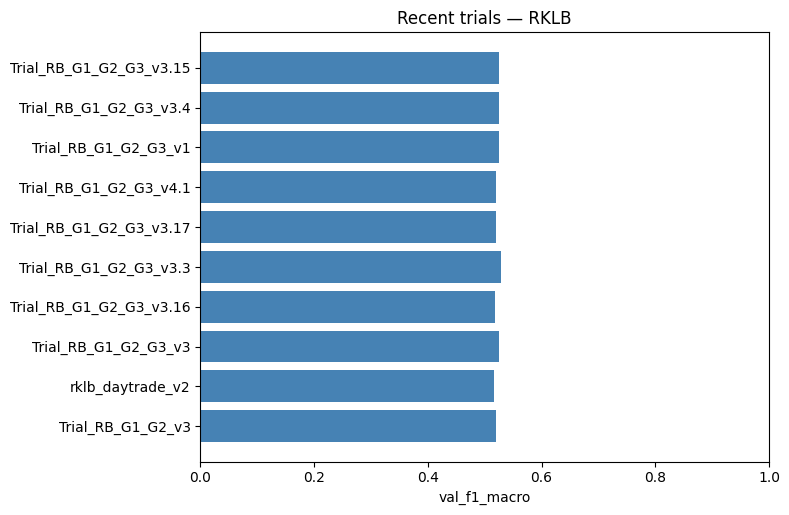

In [7]:
# Chart: prefer val_f1_macro (better for imbalanced labels), fall back to val_accuracy
import matplotlib.pyplot as plt

if log_path.is_file() and len(trials):
    plot_df = trials.copy()
    metric_col = "val_f1_macro" if "val_f1_macro" in plot_df.columns else "val_accuracy"
    plot_df = plot_df.dropna(subset=[metric_col])
    label_col = "train_experiment_name" if "train_experiment_name" in plot_df.columns else "run_id"
    plot_df["label"] = plot_df[label_col].fillna(plot_df["run_id"]).astype(str)
    plot_df = plot_df.sort_values(metric_col, ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(plot_df))))
    ax.barh(plot_df["label"], plot_df[metric_col], color="steelblue")
    ax.set_xlabel(metric_col)
    ax.set_title(f"Recent trials — {cfg.symbol.upper()}")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Nothing to plot yet.")

In [8]:
# Per-class val metrics for the latest run (or the one you just trained)

def load_latest_metrics(symbol: str, artifacts_dir: str = "artifacts") -> tuple[Path, dict]:
    sym_dir = REPO_ROOT / artifacts_dir / symbol.upper()
    if not sym_dir.is_dir():
        raise FileNotFoundError(sym_dir)
    runs = sorted(p for p in sym_dir.iterdir() if p.is_dir() and (p / "metrics.json").is_file())
    if not runs:
        raise FileNotFoundError("No runs with metrics.json")
    latest = runs[-1]
    return latest, json.loads((latest / "metrics.json").read_text(encoding="utf-8"))

run_dir = last_run_dir if last_run_dir is not None else load_latest_metrics(cfg.symbol)[0]
metrics = json.loads((run_dir / "metrics.json").read_text(encoding="utf-8"))
report = metrics.get("classification_report_val", {})
rows = []
for name, stats in report.items():
    if isinstance(stats, dict) and "f1-score" in stats:
        rows.append({"class": name, **stats})
if rows:
    display(pd.DataFrame(rows).set_index("class")[["precision", "recall", "f1-score", "support"]])
    print("Run:", run_dir.name)
else:
    print("No classification_report_val in metrics.json")

,precision,recall,f1-score,support
class,,,,
stop_loss,0.559508,0.642072,0.597953,637.0
take_profit,0.122581,0.243590,0.163090,78.0
vertical,0.856307,0.749269,0.799220,1368.0
macro avg,0.512799,0.544977,0.520088,2083.0
weighted avg,0.738068,0.697552,0.713850,2083.0


Run: 20260621T213147_869961Z
